In [4]:
import os

print("Datasets available:")
for item in os.listdir("/kaggle/input"):
    print(" -", item)

Datasets available:
 - datasets


In [5]:


DATA_PATH = "/kaggle/input/datasets"

for root, dirs, files in os.walk(DATA_PATH):
    print("\n📁", root)
    
    for file in files[:10]:
        print("   📄", file)


📁 /kaggle/input/datasets

📁 /kaggle/input/datasets/sshubam

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021
   📄 insat_3d_ds - Sheet.csv

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED
   📄 35(2).jpg
   📄 55(2).jpg
   📄 36(3).jpg
   📄 45.jpg
   📄 56.jpg
   📄 58.jpg
   📄 44(2).jpg
   📄 46(3).jpg
   📄 115.jpg
   📄 84.jpg

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_raw_cyclone_ds

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_raw_cyclone_ds/CYCLONE_DATASET_FINAL
   📄 35(2).jpg
   📄 55.JPEG
   📄 55(2).jpg
   📄 36(3).jpg
   📄 45.jpg
   📄 56.jpg
   📄 58.jpg
   📄 44(2).jpg
   📄 54 2.jpg
   📄 59_LUBAN.jpg

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_for_reference_d

In [6]:
DATASET_PATH = "/kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021"

IR_PATH = f"{DATASET_PATH}/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED"
CSV_PATH = f"{DATASET_PATH}/insat_3d_ds - Sheet.csv"

print("IR folder:", IR_PATH)
print("CSV:", CSV_PATH)

IR folder: /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED
CSV: /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat_3d_ds - Sheet.csv


In [7]:
import pandas as pd

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

Shape: (136, 2)

Columns:
['img_name', 'label']

First 10 rows:


,img_name,label
0,25.jpg,25
1,27.jpg,27
2,28.jpg,28
3,30.jpg,30
4,30(1).jpg,30
5,31.jpg,31
6,32.jpg,32
7,32(1).jpg,32
8,33.jpg,33
9,33(1).jpg,33


In [11]:
# Check duplicate image names
print("Duplicate images:", df["img_name"].duplicated().sum())

# Check whether every CSV image exists in the IR folder
missing = []

for filename in df["img_name"]:
    path = os.path.join(IR_PATH, filename)
    if not os.path.exists(path):
        missing.append(filename)

print("Missing images:", len(missing))
print("Examples:", missing[:20])

# Check labels
print("\nLabel counts:")
print(df["label"].value_counts())

# Show the dataset structure
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 20 rows:")
display(df.head(20))

Duplicate images: 0
Missing images: 0
Examples: []

Label counts:
label
45     5
47     5
59     4
48     4
35     4
      ..
112    1
115    1
118    1
119    1
128    1
Name: count, Length: 66, dtype: int64

Columns:
['img_name', 'label']

First 20 rows:


,img_name,label
0,25.jpg,25
1,27.jpg,27
2,28.jpg,28
3,30.jpg,30
4,30(1).jpg,30
5,31.jpg,31
6,32.jpg,32
7,32(1).jpg,32
8,33.jpg,33
9,33(1).jpg,33


INSAT-3D DATASET INSPECTION

[1] CSV INFORMATION
----------------------------------------------------------------------
CSV path: /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat_3d_ds - Sheet.csv
Dataset shape: (136, 2)
Columns: ['img_name', 'label']

First 20 rows:


,img_name,label
0,25.jpg,25
1,27.jpg,27
2,28.jpg,28
3,30.jpg,30
4,30(1).jpg,30
5,31.jpg,31
6,32.jpg,32
7,32(1).jpg,32
8,33.jpg,33
9,33(1).jpg,33



[2] MISSING VALUES
----------------------------------------------------------------------
img_name    0
label       0
dtype: int64

[3] DUPLICATE CHECK
----------------------------------------------------------------------
Duplicate rows: 0
Duplicate image names: 0

[4] IMAGE-CVS MATCHING
----------------------------------------------------------------------
Images listed in CSV: 136
Images found in IR folder: 136
Missing images: 0
✓ Every CSV image exists in the IR folder.

[5] LABEL INFORMATION
----------------------------------------------------------------------
Number of unique labels: 66

Unique wind-speed labels:
[np.int64(25), np.int64(27), np.int64(28), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int

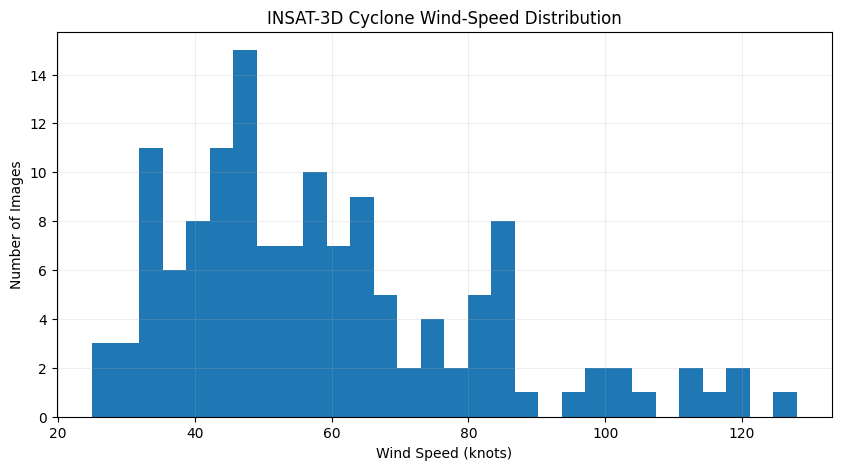


SUMMARY
Total images in CSV: 136
Unique wind-speed labels: 66
Missing CSV values: 0
Duplicate rows: 0
Duplicate image names: 0
Missing image files: 0

✓ Initial dataset inspection complete.


In [12]:
# ============================================================
# INSAT-3D DATASET — INITIAL INSPECTION & VALIDATION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 1. Define paths
# ------------------------------------------------------------

BASE = "/kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021"

CSV_PATH = os.path.join(BASE, "insat_3d_ds - Sheet.csv")

IR_PATH = os.path.join(
    BASE,
    "insat3d_ir_cyclone_ds",
    "CYCLONE_DATASET_INFRARED"
)

RAW_PATH = os.path.join(
    BASE,
    "insat3d_raw_cyclone_ds",
    "CYCLONE_DATASET_FINAL"
)

REFERENCE_PATH = os.path.join(
    BASE,
    "insat3d_for_reference_ds",
    "CYCLONE_DATASET"
)

print("=" * 70)
print("INSAT-3D DATASET INSPECTION")
print("=" * 70)


# ------------------------------------------------------------
# 2. Load CSV
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

print("\n[1] CSV INFORMATION")
print("-" * 70)

print("CSV path:", CSV_PATH)
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nFirst 20 rows:")
display(df.head(20))


# ------------------------------------------------------------
# 3. Check missing values
# ------------------------------------------------------------

print("\n[2] MISSING VALUES")
print("-" * 70)

print(df.isnull().sum())


# ------------------------------------------------------------
# 4. Check duplicates
# ------------------------------------------------------------

print("\n[3] DUPLICATE CHECK")
print("-" * 70)

print("Duplicate rows:",
      df.duplicated().sum())

print("Duplicate image names:",
      df["img_name"].duplicated().sum())


# ------------------------------------------------------------
# 5. Check whether every CSV image exists
# ------------------------------------------------------------

print("\n[4] IMAGE-CVS MATCHING")
print("-" * 70)

missing = []

for filename in df["img_name"]:
    image_path = os.path.join(IR_PATH, str(filename))

    if not os.path.exists(image_path):
        missing.append(filename)

print("Images listed in CSV:", len(df))
print("Images found in IR folder:",
      len(df) - len(missing))
print("Missing images:", len(missing))

if missing:
    print("\nFirst missing images:")
    print(missing[:20])
else:
    print("✓ Every CSV image exists in the IR folder.")


# ------------------------------------------------------------
# 6. Check label information
# ------------------------------------------------------------

print("\n[5] LABEL INFORMATION")
print("-" * 70)

print("Number of unique labels:",
      df["label"].nunique())

print("\nUnique wind-speed labels:")
print(sorted(df["label"].unique()))

print("\nLabel frequency:")
print(df["label"].value_counts().sort_index())


# ------------------------------------------------------------
# 7. Basic statistics of wind speed
# ------------------------------------------------------------

print("\n[6] WIND-SPEED STATISTICS")
print("-" * 70)

print(df["label"].describe())


# ------------------------------------------------------------
# 8. Inspect all three dataset folders
# ------------------------------------------------------------

print("\n[7] DATASET FOLDER INFORMATION")
print("-" * 70)

folders = {
    "IR": IR_PATH,
    "RAW": RAW_PATH,
    "REFERENCE": REFERENCE_PATH
}

for name, path in folders.items():

    print(f"\n{name} DATASET")
    print("Path:", path)

    if os.path.exists(path):

        files = [
            f for f in os.listdir(path)
            if os.path.isfile(os.path.join(path, f))
        ]

        print("Number of files:", len(files))

        print("First 20 files:")
        for f in files[:20]:
            print("   ", f)

    else:
        print("⚠ Folder not found!")


# ------------------------------------------------------------
# 9. Inspect a few IR images
# ------------------------------------------------------------

print("\n[8] IR IMAGE INSPECTION")
print("-" * 70)

ir_files = [
    f for f in os.listdir(IR_PATH)
    if os.path.isfile(os.path.join(IR_PATH, f))
]

print("Total IR images:", len(ir_files))

# Inspect first 5 images
for filename in ir_files[:5]:

    image_path = os.path.join(IR_PATH, filename)

    try:
        img = Image.open(image_path)

        print(
            f"{filename:20s} | "
            f"Size: {img.size} | "
            f"Mode: {img.mode}"
        )

    except Exception as e:
        print(f"Could not open {filename}: {e}")


# ------------------------------------------------------------
# 10. Wind-speed distribution plot
# ------------------------------------------------------------

print("\n[9] WIND-SPEED DISTRIBUTION")
print("-" * 70)

plt.figure(figsize=(10, 5))

plt.hist(
    df["label"],
    bins=30
)

plt.xlabel("Wind Speed (knots)")
plt.ylabel("Number of Images")
plt.title("INSAT-3D Cyclone Wind-Speed Distribution")

plt.grid(alpha=0.2)
plt.show()


# ------------------------------------------------------------
# 11. Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print("Total images in CSV:", len(df))
print("Unique wind-speed labels:", df["label"].nunique())
print("Missing CSV values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate image names:", df["img_name"].duplicated().sum())
print("Missing image files:", len(missing))

print("\n✓ Initial dataset inspection complete.")
print("=" * 70)

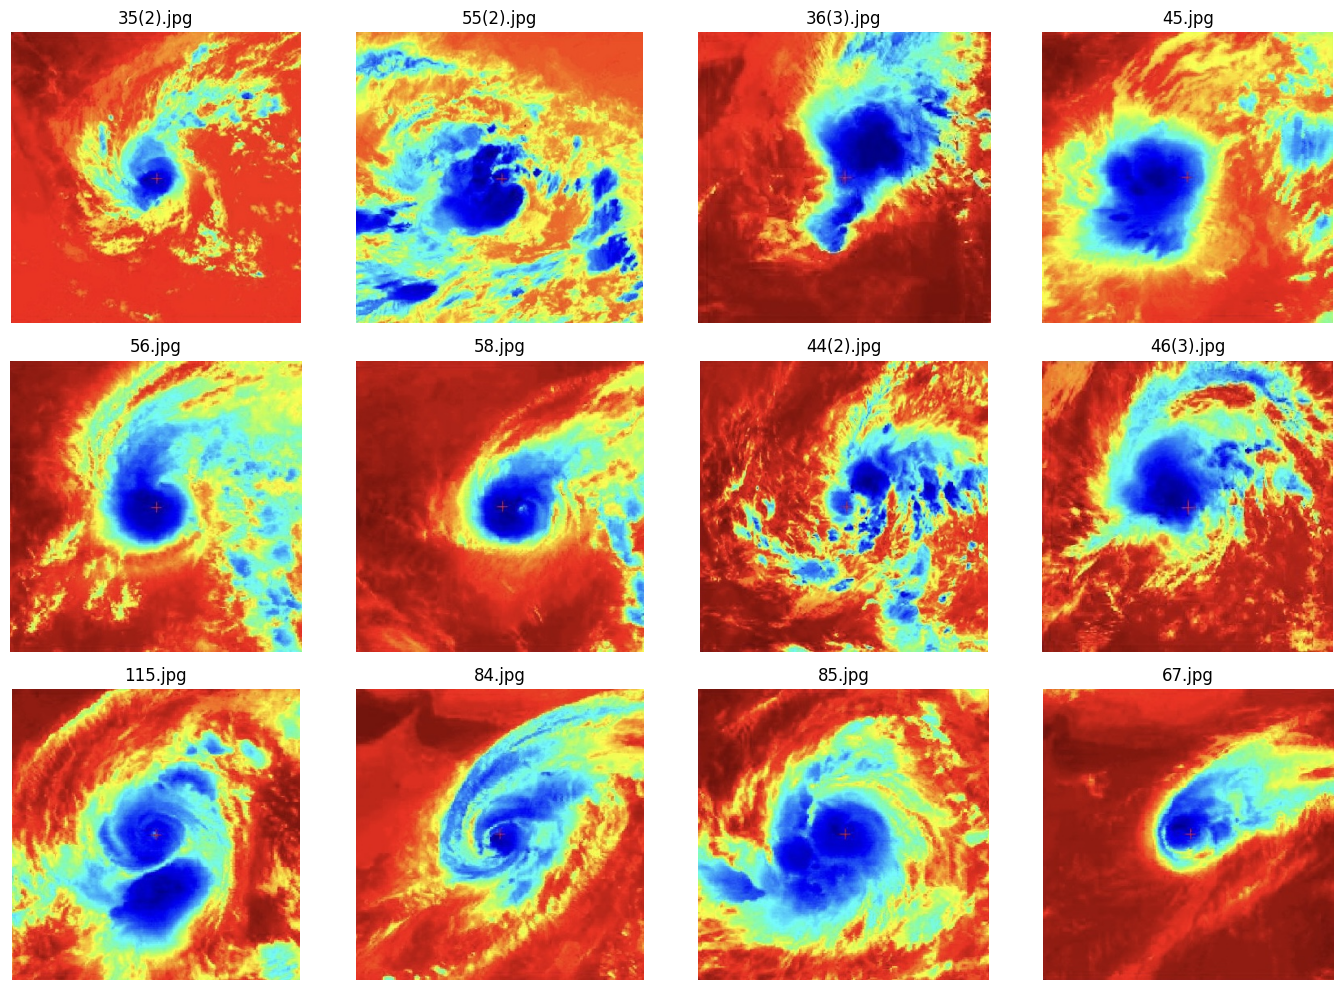

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import math

# Select 12 IR images
sample_files = ir_files[:12]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for ax, filename in zip(axes, sample_files):
    path = os.path.join(IR_PATH, filename)
    img = Image.open(path)

    ax.imshow(img)
    ax.set_title(filename)
    ax.axis("off")

plt.tight_layout()
plt.show()

INSAT-3D COMPREHENSIVE DATASET INSPECTION

[1] DATASET OVERVIEW
---------------------------------------------------------------------------
Dataset shape: (136, 2)
Number of images: 136
Columns: ['img_name', 'label']

First 10 rows:


,img_name,label
0,25.jpg,25
1,27.jpg,27
2,28.jpg,28
3,30.jpg,30
4,30(1).jpg,30
5,31.jpg,31
6,32.jpg,32
7,32(1).jpg,32
8,33.jpg,33
9,33(1).jpg,33



[2] DATA QUALITY
---------------------------------------------------------------------------
Missing values:
img_name    0
label       0
dtype: int64

Duplicate rows: 0
Duplicate image names: 0

[3] CSV ↔ IMAGE MATCHING
---------------------------------------------------------------------------
Images listed in CSV: 136
Images found: 136
Missing images: 0
✓ All CSV images exist in the IR folder.

[4] IMAGE FORMAT INSPECTION
---------------------------------------------------------------------------
Unique image sizes:
Counter({(357, 358): 10, (356, 357): 6, (358, 358): 6, (358, 357): 6, (356, 358): 6, (357, 357): 5, (355, 359): 5, (354, 357): 4, (357, 359): 4, (356, 355): 4, (359, 357): 4, (358, 359): 4, (359, 356): 4, (359, 359): 3, (360, 357): 3, (356, 359): 3, (358, 356): 3, (261, 262): 3, (356, 356): 3, (259, 260): 2, (355, 355): 2, (359, 355): 2, (260, 260): 2, (356, 354): 2, (260, 262): 2, (261, 259): 2, (356, 353): 2, (352, 357): 1, (360, 354): 1, (354, 349): 1, (360, 358): 1, 

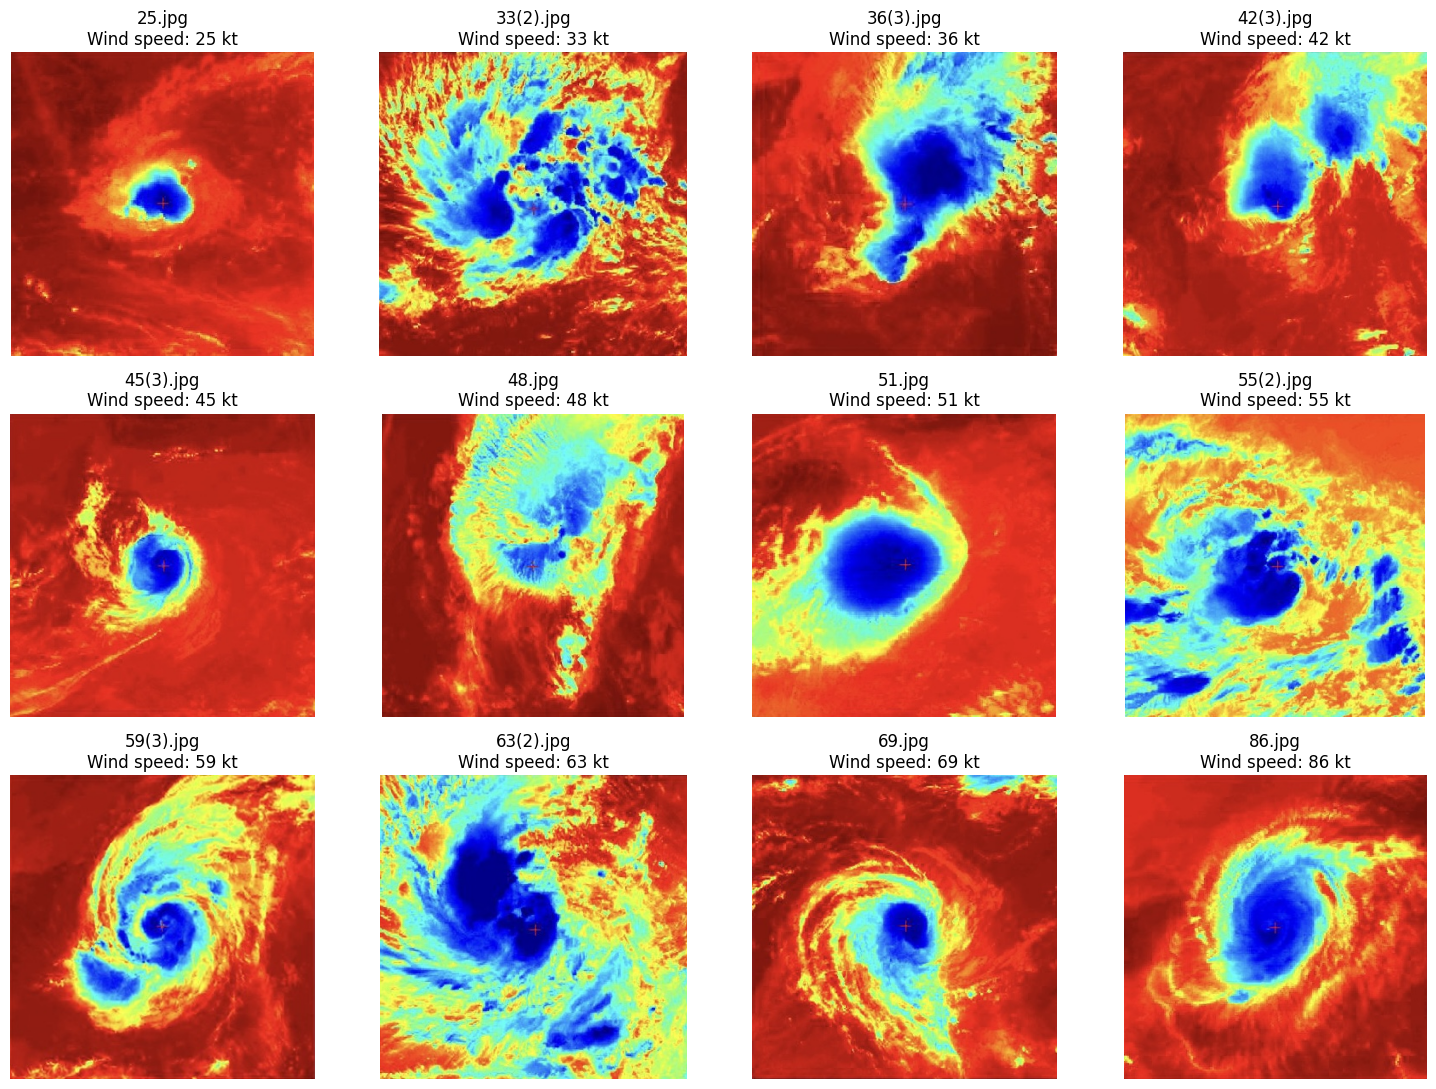


[6] WIND SPEED INFORMATION
---------------------------------------------------------------------------
Number of unique wind speeds: 66

Wind speed statistics:
count    136.000000
mean      58.897059
std       22.043485
min       25.000000
25%       44.000000
50%       53.500000
75%       69.250000
max      128.000000
Name: label, dtype: float64

Wind speed frequency:


,image_count
label,
25,1
27,1
28,1
30,2
31,1
...,...
112,1
115,1
118,1



[7] WIND SPEED DISTRIBUTION
---------------------------------------------------------------------------


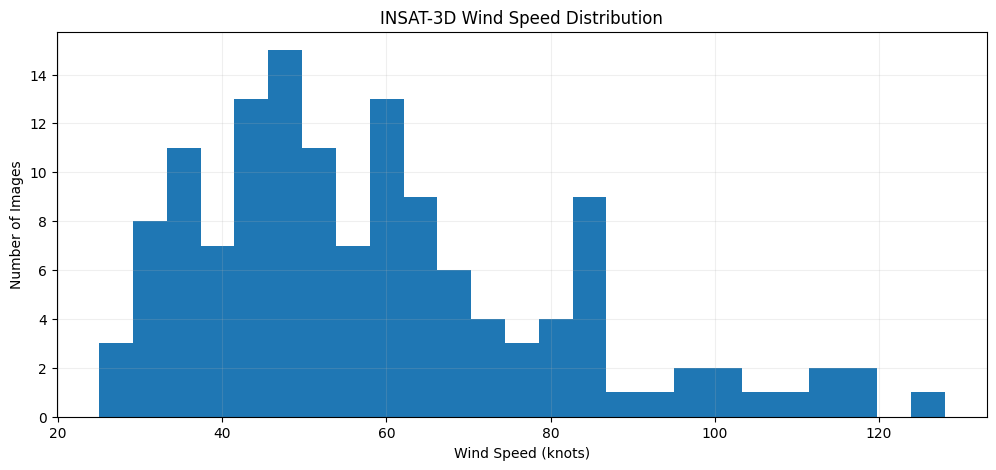


[8] CYCLONE CATEGORY DISTRIBUTION
---------------------------------------------------------------------------


,image_count
category,
Severe Cyclonic Storm,41
Cyclonic Storm,39
Very Severe Cyclonic Storm,33
Extremely Severe Cyclonic Storm,11
Deep Depression,9
Depression,2
Super Cyclonic Storm,1



Category percentages:


,percentage
category,
Severe Cyclonic Storm,30.15
Cyclonic Storm,28.68
Very Severe Cyclonic Storm,24.26
Extremely Severe Cyclonic Storm,8.09
Deep Depression,6.62
Depression,1.47
Super Cyclonic Storm,0.74



[9] CLASS BALANCE CHECK
---------------------------------------------------------------------------
✓ Severe Cyclonic Storm: 41 images
✓ Cyclonic Storm: 39 images
✓ Very Severe Cyclonic Storm: 33 images
✓ Extremely Severe Cyclonic Storm: 11 images
✓ Deep Depression: 9 images
⚠ Depression: only 2 image(s)
⚠ Super Cyclonic Storm: only 1 image(s)

[10] STORM ID CHECK
---------------------------------------------------------------------------
Available CSV columns:
['img_name', 'label', 'category']
⚠ No storm/cyclone ID column exists in the CSV.
The current CSV only provides image name + wind-speed label.
We must find another reliable source for storm identity before doing the required storm-wise split.

FINAL SUMMARY
Total images              : 136
Unique wind speeds        : 66
Missing CSV values        : 0
Duplicate rows            : 0
Duplicate image names     : 0
Missing image files       : 0
Corrupt/unreadable images : 0
Unique image sizes        : 61
Image modes               : {'R

In [1]:
# ============================================================
# INSAT-3D — COMPREHENSIVE DATASET INSPECTION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE = "/kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021"

CSV_PATH = os.path.join(BASE, "insat_3d_ds - Sheet.csv")

IR_PATH = os.path.join(
    BASE,
    "insat3d_ir_cyclone_ds",
    "CYCLONE_DATASET_INFRARED"
)

print("=" * 75)
print("INSAT-3D COMPREHENSIVE DATASET INSPECTION")
print("=" * 75)


# ------------------------------------------------------------
# 2. LOAD CSV
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

print("\n[1] DATASET OVERVIEW")
print("-" * 75)

print("Dataset shape:", df.shape)
print("Number of images:", len(df))
print("Columns:", df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))


# ------------------------------------------------------------
# 3. BASIC DATA QUALITY
# ------------------------------------------------------------

print("\n[2] DATA QUALITY")
print("-" * 75)

missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate image names:", df["img_name"].duplicated().sum())


# ------------------------------------------------------------
# 4. CSV ↔ IMAGE MATCHING
# ------------------------------------------------------------

print("\n[3] CSV ↔ IMAGE MATCHING")
print("-" * 75)

missing_images = []

for filename in df["img_name"]:

    image_path = os.path.join(IR_PATH, str(filename))

    if not os.path.isfile(image_path):
        missing_images.append(filename)

print("Images listed in CSV:", len(df))
print("Images found:", len(df) - len(missing_images))
print("Missing images:", len(missing_images))

if missing_images:
    print("\nFirst missing images:")
    print(missing_images[:20])
else:
    print("✓ All CSV images exist in the IR folder.")


# ------------------------------------------------------------
# 5. IMAGE FORMAT INSPECTION
# ------------------------------------------------------------

print("\n[4] IMAGE FORMAT INSPECTION")
print("-" * 75)

sizes = []
modes = []
corrupt_images = []

for filename in df["img_name"]:

    image_path = os.path.join(IR_PATH, str(filename))

    try:
        with Image.open(image_path) as img:
            sizes.append(img.size)
            modes.append(img.mode)

    except Exception as e:
        corrupt_images.append((filename, str(e)))

print("Unique image sizes:")
print(Counter(sizes))

print("\nImage modes:")
print(Counter(modes))

print("\nCorrupt/unreadable images:", len(corrupt_images))

if corrupt_images:
    print(corrupt_images[:10])
else:
    print("✓ All images can be opened successfully.")


# ------------------------------------------------------------
# 6. DISPLAY 12 REPRESENTATIVE IMAGES
# ------------------------------------------------------------

print("\n[5] REPRESENTATIVE IR IMAGES")
print("-" * 75)

# Select images from different parts of the dataframe
indices = [
    0, 10, 20, 30,
    40, 50, 60, 70,
    80, 90, 100, 120
]

# Make sure indices exist
indices = [i for i in indices if i < len(df)]

fig, axes = plt.subplots(3, 4, figsize=(15, 11))
axes = axes.flatten()

for ax, idx in zip(axes, indices):

    filename = df.iloc[idx]["img_name"]
    label = df.iloc[idx]["label"]

    image_path = os.path.join(IR_PATH, str(filename))

    try:
        img = Image.open(image_path)

        ax.imshow(img)
        ax.set_title(
            f"{filename}\nWind speed: {label} kt"
        )
        ax.axis("off")

    except Exception:
        ax.set_title(f"{filename}\nERROR")
        ax.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. WIND SPEED INFORMATION
# ------------------------------------------------------------

print("\n[6] WIND SPEED INFORMATION")
print("-" * 75)

print("Number of unique wind speeds:",
      df["label"].nunique())

print("\nWind speed statistics:")
print(df["label"].describe())

print("\nWind speed frequency:")
display(
    df["label"]
    .value_counts()
    .sort_index()
    .to_frame("image_count")
)


# ------------------------------------------------------------
# 8. WIND SPEED DISTRIBUTION
# ------------------------------------------------------------

print("\n[7] WIND SPEED DISTRIBUTION")
print("-" * 75)

plt.figure(figsize=(12, 5))

plt.hist(
    df["label"],
    bins=25
)

plt.xlabel("Wind Speed (knots)")
plt.ylabel("Number of Images")
plt.title("INSAT-3D Wind Speed Distribution")
plt.grid(alpha=0.2)

plt.show()


# ------------------------------------------------------------
# 9. CONVERT WIND SPEED → CYCLONE CATEGORY
#    FOR INSPECTION ONLY
# ------------------------------------------------------------

def wind_to_category(wind):

    if 17 <= wind <= 27:
        return "Depression"

    elif 28 <= wind <= 33:
        return "Deep Depression"

    elif 34 <= wind <= 47:
        return "Cyclonic Storm"

    elif 48 <= wind <= 63:
        return "Severe Cyclonic Storm"

    elif 64 <= wind <= 89:
        return "Very Severe Cyclonic Storm"

    elif 90 <= wind <= 119:
        return "Extremely Severe Cyclonic Storm"

    elif wind >= 120:
        return "Super Cyclonic Storm"

    else:
        return "Outside defined range"


df["category"] = df["label"].apply(wind_to_category)


# ------------------------------------------------------------
# 10. CATEGORY DISTRIBUTION
# ------------------------------------------------------------

print("\n[8] CYCLONE CATEGORY DISTRIBUTION")
print("-" * 75)

category_counts = (
    df["category"]
    .value_counts()
)

display(
    category_counts
    .to_frame("image_count")
)

print("\nCategory percentages:")

category_percent = (
    df["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(
    category_percent
    .to_frame("percentage")
)


# ------------------------------------------------------------
# 11. CHECK FOR VERY SMALL CLASSES
# ------------------------------------------------------------

print("\n[9] CLASS BALANCE CHECK")
print("-" * 75)

for category, count in category_counts.items():

    if count < 5:
        print(
            f"⚠ {category}: only {count} image(s)"
        )

    else:
        print(
            f"✓ {category}: {count} images"
        )


# ------------------------------------------------------------
# 12. STORM-ID AVAILABILITY CHECK
# ------------------------------------------------------------

print("\n[10] STORM ID CHECK")
print("-" * 75)

print("Available CSV columns:")
print(df.columns.tolist())

if "storm_id" in df.columns:
    print("✓ Storm ID is available.")
elif "storm" in df.columns:
    print("✓ Storm information appears to be available.")
elif "cyclone" in df.columns:
    print("✓ Cyclone information appears to be available.")
else:
    print(
        "⚠ No storm/cyclone ID column exists in the CSV."
    )
    print(
        "The current CSV only provides image name + wind-speed label."
    )
    print(
        "We must find another reliable source for storm identity "
        "before doing the required storm-wise split."
    )


# ------------------------------------------------------------
# 13. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL SUMMARY")
print("=" * 75)

print(f"Total images              : {len(df)}")
print(f"Unique wind speeds        : {df['label'].nunique()}")
print(f"Missing CSV values        : {df.isnull().sum().sum()}")
print(f"Duplicate rows            : {df.duplicated().sum()}")
print(f"Duplicate image names     : {df['img_name'].duplicated().sum()}")
print(f"Missing image files       : {len(missing_images)}")
print(f"Corrupt/unreadable images : {len(corrupt_images)}")
print(f"Unique image sizes        : {len(set(sizes))}")
print(f"Image modes               : {dict(Counter(modes))}")
print(f"Number of categories      : {df['category'].nunique()}")

print("\n✓ Comprehensive inspection complete.")
print("=" * 75)

In [3]:
for root, dirs, files in os.walk("/kaggle/input"):

    if "tcir" in root.lower() or "tropical" in root.lower():
        print("📁", root)

    for file in files:
        if "tcir" in file.lower() or "tropical" in file.lower():
            print("   📄", os.path.join(root, file))

📁 /kaggle/input/datasets/kbdharun/tropical-cyclone-intensity-regression


In [5]:
import os

BASE = "/kaggle/input"

print("=" * 70)
print("KAGGLE DATASET STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk(BASE):

    # Only show directories up to a reasonable depth
    depth = root.replace(BASE, "").count(os.sep)

    if depth <= 5:
        print(f"\n📁 {root}")

        if files:
            print(f"   Number of files: {len(files)}")
            print("   Examples:")

            for f in files[:15]:
                print("      📄", f)

KAGGLE DATASET STRUCTURE

📁 /kaggle/input

📁 /kaggle/input/datasets

📁 /kaggle/input/datasets/kbdharun

📁 /kaggle/input/datasets/kbdharun/tropical-cyclone-intensity-regression
   Number of files: 1
   Examples:
      📄 ir.npy

📁 /kaggle/input/datasets/sshubam

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021
   Number of files: 1
   Examples:
      📄 insat_3d_ds - Sheet.csv

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED
   Number of files: 136
   Examples:
      📄 35(2).jpg
      📄 55(2).jpg
      📄 36(3).jpg
      📄 45.jpg
      📄 56.jpg
      📄 58.jpg
      📄 44(2).jpg
      📄 46(3).jpg
      📄 115.jpg
      📄 84.jpg
      📄 85.jpg
      📄 67.jpg
      📄 118.jpg
      📄 84(1).jpg
      📄 82.jpg

📁 /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


CYCLONE IMAGE DATASET — FILE INSPECTION

[1] Cyclone_Images.h5
---------------------------------------------------------------------------
File size: 5269.0 MB

HDF5 contents:
  DATASET: Images | shape=(21076, 128, 128, 4) | dtype=float32

File attributes:

[2] Cyclone_Labels h5.npy
---------------------------------------------------------------------------
File size: 1.74 MB
Type: <class 'numpy.ndarray'>
Shape: (21076, 8)
Dtype: object

First few labels:
[['ATLN' '200301L' -66.0 31.4 '2003041815' 30.0 0.0 1008.0]
 ['ATLN' '200301L' -66.3 31.9 '2003041818' 30.0 0.0 1007.0]
 ['ATLN' '200301L' -66.6 32.5 '2003041821' 30.0 0.0 1007.0]
 ['ATLN' '200301L' -68.6 34.5 '2003041912' 35.0 0.0 1006.0]
 ['ATLN' '200301L' -68.8 34.4 '2003041915' 35.0 0.0 1006.0]
 ['ATLN' '200301L' -69.1 34.3 '2003041918' 35.0 0.0 1006.0]
 ['ATLN' '200301L' -69.0 34.0 '2003041921' 38.0 0.0 1006.0]
 ['ATLN' '200301L' -68.2 32.0 '2003042012' 45.0 0.0 1000.0]
 ['ATLN' '200301L' -67.8 31.9 '2003042015' 45.0 0.0 999.0]
 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


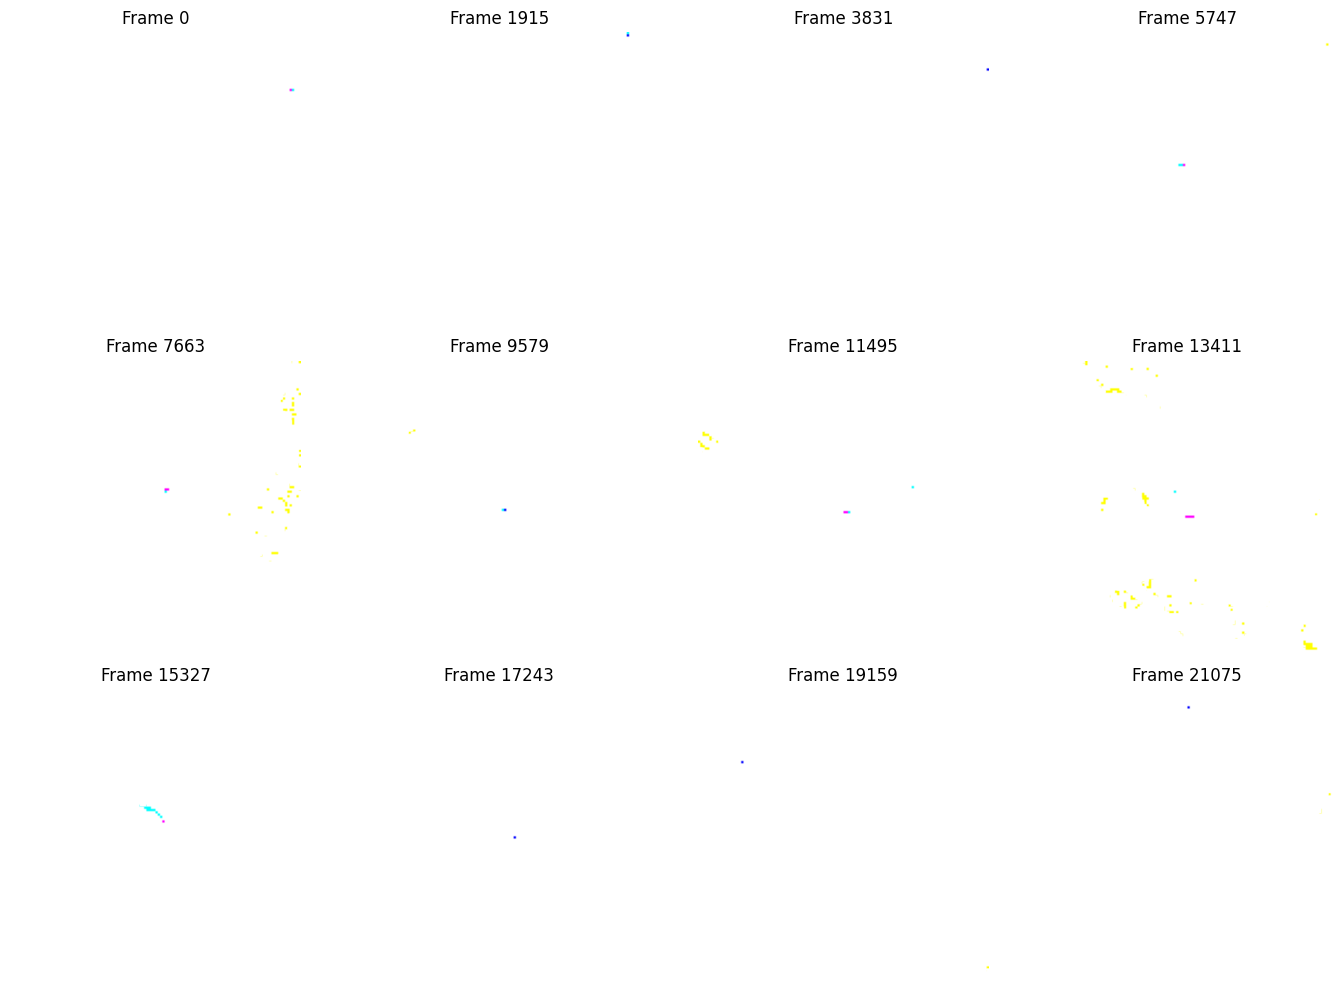


INSPECTION COMPLETE
Image file exists: True
Label file exists: True
Labels loaded: 21076


In [7]:
import h5py
import numpy as np
import os

DATASET_PATH = "/kaggle/input/datasets/vaukaofworlds/thecycloneimagedataset"

IMAGE_FILE = os.path.join(DATASET_PATH, "Cyclone_Images.h5")
LABEL_FILE = os.path.join(DATASET_PATH, "Cyclone_Labels h5.npy")

print("=" * 75)
print("CYCLONE IMAGE DATASET — FILE INSPECTION")
print("=" * 75)

# ============================================================
# 1. HDF5 FILE
# ============================================================

print("\n[1] Cyclone_Images.h5")
print("-" * 75)

print("File size:",
      round(os.path.getsize(IMAGE_FILE) / (1024**2), 2),
      "MB")

with h5py.File(IMAGE_FILE, "r") as f:

    print("\nHDF5 contents:")

    def show_h5(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f"  DATASET: {name}"
                f" | shape={obj.shape}"
                f" | dtype={obj.dtype}"
            )
        elif isinstance(obj, h5py.Group):
            print(f"  GROUP:   {name}")

    f.visititems(show_h5)

    print("\nFile attributes:")
    for key, value in f.attrs.items():
        print(f"  {key}: {value}")


# ============================================================
# 2. LABEL FILE
# ============================================================

print("\n[2] Cyclone_Labels h5.npy")
print("-" * 75)

print("File size:",
      round(os.path.getsize(LABEL_FILE) / (1024**2), 2),
      "MB")

labels = np.load(
    LABEL_FILE,
    allow_pickle=True
)

print("Type:", type(labels))
print("Shape:", labels.shape)
print("Dtype:", labels.dtype)

print("\nFirst few labels:")

try:
    print(labels[:10])
except Exception as e:
    print("Could not display labels:", e)


# ============================================================
# 3. CHECK IMAGE COUNT VS LABEL COUNT
# ============================================================

print("\n[3] IMAGE ↔ LABEL COUNT")
print("-" * 75)

with h5py.File(IMAGE_FILE, "r") as f:

    datasets = []

    def collect_datasets(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets.append((name, obj.shape))

    f.visititems(collect_datasets)

    print("Datasets found:")
    for name, shape in datasets:
        print(" ", name, "→", shape)

print("\nNumber of labels:", len(labels))


# ============================================================
# 4. TRY TO DISPLAY SAMPLE IMAGES
# ============================================================

print("\n[4] SAMPLE IMAGE VISUALIZATION")
print("-" * 75)

import matplotlib.pyplot as plt

with h5py.File(IMAGE_FILE, "r") as f:

    # Find the first actual dataset
    image_dataset = None

    def find_first_dataset(name, obj):
        global image_dataset

        if image_dataset is None and isinstance(obj, h5py.Dataset):
            image_dataset = obj

    f.visititems(find_first_dataset)

    if image_dataset is not None:

        print("Using dataset:",
              image_dataset.name)

        print("Shape:",
              image_dataset.shape)

        n = min(12, image_dataset.shape[0])

        indices = np.linspace(
            0,
            image_dataset.shape[0] - 1,
            n,
            dtype=int
        )

        fig, axes = plt.subplots(
            3, 4,
            figsize=(14, 10)
        )

        axes = axes.flatten()

        for ax, idx in zip(axes, indices):

            img = image_dataset[idx]

            # Remove unnecessary dimensions
            img = np.squeeze(img)

            ax.imshow(
                img,
                cmap="gray" if img.ndim == 2 else None
            )

            ax.set_title(
                f"Frame {idx}"
            )

            ax.axis("off")

        plt.tight_layout()
        plt.show()

    else:

        print("⚠ No HDF5 image dataset found.")


# ============================================================
# 5. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("INSPECTION COMPLETE")
print("=" * 75)

print("Image file exists:", os.path.exists(IMAGE_FILE))
print("Label file exists:", os.path.exists(LABEL_FILE))
print("Labels loaded:", len(labels))

print("=" * 75)

In [8]:
import numpy as np
import pandas as pd

LABEL_FILE = "/kaggle/input/datasets/vaukaofworlds/thecycloneimagedataset/Cyclone_Labels h5.npy"

labels = np.load(LABEL_FILE, allow_pickle=True)

# Convert to DataFrame
df = pd.DataFrame(labels)

# Give the 8 columns meaningful names
df.columns = [
    "basin",
    "storm_id",
    "longitude",
    "latitude",
    "timestamp",
    "wind_speed",
    "unknown",
    "pressure"
]

print("Dataset shape:", df.shape)

print("\nBasin counts:")
print(df["basin"].value_counts())

print("\nExample rows:")
display(df.head())

print("\nUnique basins:")
print(df["basin"].unique())

Dataset shape: (21076, 8)

Basin counts:
basin
WPAC    8922
ATLN    7144
EPAC    5010
Name: count, dtype: int64

Example rows:


,basin,storm_id,longitude,latitude,timestamp,wind_speed,unknown,pressure
0,ATLN,200301L,-66.0,31.4,2003041815,30.0,0.0,1008.0
1,ATLN,200301L,-66.3,31.9,2003041818,30.0,0.0,1007.0
2,ATLN,200301L,-66.6,32.5,2003041821,30.0,0.0,1007.0
3,ATLN,200301L,-68.6,34.5,2003041912,35.0,0.0,1006.0
4,ATLN,200301L,-68.8,34.4,2003041915,35.0,0.0,1006.0



Unique basins:
['ATLN' 'EPAC' 'WPAC']


In [2]:
# ============================================================
# INSAT-3D PREPROCESSING + CATEGORY CREATION + DATA SPLIT
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

IR_PATH = (
    "/kaggle/input/datasets/sshubam/"
    "insat3d-infrared-raw-cyclone-images-20132021/"
    "insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED"
)

CSV_PATH = (
    "/kaggle/input/datasets/sshubam/"
    "insat3d-infrared-raw-cyclone-images-20132021/"
    "insat_3d_ds - Sheet.csv"
)

# ------------------------------------------------------------
# 2. LOAD CSV
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

print("=" * 70)
print("INSAT-3D PREPROCESSING")
print("=" * 70)

print("\nOriginal dataset:", df.shape)

# ------------------------------------------------------------
# 3. BASIC CLEANING
# ------------------------------------------------------------

# Remove accidental whitespace from column names
df.columns = df.columns.str.strip()

# Remove rows with missing image names or labels
df = df.dropna(subset=["img_name", "label"]).copy()

# Make sure wind speed is numeric
df["label"] = pd.to_numeric(df["label"], errors="coerce")

# Remove rows where wind speed could not be converted
df = df.dropna(subset=["label"]).copy()

# Make sure each image actually exists
df["image_path"] = df["img_name"].apply(
    lambda x: os.path.join(IR_PATH, str(x))
)

df = df[df["image_path"].apply(os.path.exists)].copy()

# Remove duplicate image names
df = df.drop_duplicates(subset=["img_name"]).reset_index(drop=True)

print("After basic cleaning:", df.shape)

# ------------------------------------------------------------
# 4. CREATE CYCLONE CATEGORIES
# ------------------------------------------------------------

def wind_to_category(wind):

    if 17 <= wind <= 27:
        return "Depression"

    elif 28 <= wind <= 33:
        return "Deep Depression"

    elif 34 <= wind <= 47:
        return "Cyclonic Storm"

    elif 48 <= wind <= 63:
        return "Severe Cyclonic Storm"

    elif 64 <= wind <= 89:
        return "Very Severe Cyclonic Storm"

    elif 90 <= wind <= 119:
        return "Extremely Severe Cyclonic Storm"

    elif wind >= 120:
        return "Super Cyclonic Storm"

    else:
        return "Unknown"


df["category"] = df["label"].apply(wind_to_category)

# Remove anything outside the cyclone classification range
df = df[df["category"] != "Unknown"].copy()

# ------------------------------------------------------------
# 5. ENCODE CATEGORY AS INTEGER
# ------------------------------------------------------------

category_order = [
    "Depression",
    "Deep Depression",
    "Cyclonic Storm",
    "Severe Cyclonic Storm",
    "Very Severe Cyclonic Storm",
    "Extremely Severe Cyclonic Storm",
    "Super Cyclonic Storm"
]

category_to_id = {
    category: i
    for i, category in enumerate(category_order)
}

df["class_id"] = df["category"].map(category_to_id)

# ------------------------------------------------------------
# 6. SHOW CATEGORY DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("CATEGORY DISTRIBUTION")
print("-" * 70)

print(
    df["category"]
    .value_counts()
    .reindex(category_order)
    .fillna(0)
)

# ------------------------------------------------------------
# 7. IMPORTANT DATASET LIMITATION
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("STORM-WISE SPLIT CHECK")
print("-" * 70)

print(
    "⚠ No storm/cyclone ID is available in the CSV."
)

print(
    "Therefore an exact storm-wise split cannot be performed "
    "with this Kaggle copy."
)

# ------------------------------------------------------------
# 8. REMOVE CLASSES THAT CANNOT BE STRATIFIED
# ------------------------------------------------------------

# Stratified train/validation/test splitting requires
# at least 2 samples in a class.

counts = df["class_id"].value_counts()

valid_classes = counts[counts >= 2].index

removed_classes = [
    category_order[i]
    for i in category_to_id.values()
    if i not in valid_classes
]

if removed_classes:
    print("\n⚠ Classes with fewer than 2 images:")
    for c in removed_classes:
        print("   ", c)

    print(
        "\nThese classes cannot reliably participate in a "
        "stratified split with this tiny dataset."
    )

# Keep only classes with >= 2 samples
df = df[df["class_id"].isin(valid_classes)].copy()

# ------------------------------------------------------------
# 9. TRAIN / VALIDATION / TEST SPLIT
# ------------------------------------------------------------

# First: 80% train, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["class_id"]
)

# Then split temporary into:
# 10% validation
# 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_id"]
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# 10. SPLIT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SPLIT")
print("=" * 70)

print(
    f"Train      : {len(train_df)} images "
    f"({len(train_df)/len(df)*100:.1f}%)"
)

print(
    f"Validation : {len(val_df)} images "
    f"({len(val_df)/len(df)*100:.1f}%)"
)

print(
    f"Test       : {len(test_df)} images "
    f"({len(test_df)/len(df)*100:.1f}%)"
)

# ------------------------------------------------------------
# 11. CHECK CLASS DISTRIBUTION IN EACH SPLIT
# ------------------------------------------------------------

print("\nTRAIN:")
print(
    train_df["category"]
    .value_counts()
    .reindex(category_order)
    .fillna(0)
)

print("\nVALIDATION:")
print(
    val_df["category"]
    .value_counts()
    .reindex(category_order)
    .fillna(0)
)

print("\nTEST:")
print(
    test_df["category"]
    .value_counts()
    .reindex(category_order)
    .fillna(0)
)

# ------------------------------------------------------------
# 12. SAVE SPLIT CSVs
# ------------------------------------------------------------

train_df.to_csv("/kaggle/working/train.csv", index=False)
val_df.to_csv("/kaggle/working/val.csv", index=False)
test_df.to_csv("/kaggle/working/test.csv", index=False)

print("\nSaved:")
print("  /kaggle/working/train.csv")
print("  /kaggle/working/val.csv")
print("  /kaggle/working/test.csv")

# ------------------------------------------------------------
# 13. FINAL DATAFRAME PREVIEW
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATAFRAME")
print("=" * 70)

display(
    df[
        [
            "img_name",
            "label",
            "category",
            "class_id",
            "image_path"
        ]
    ].head(10)
)

print("\n✓ PREPROCESSING COMPLETE")

INSAT-3D PREPROCESSING

Original dataset: (136, 2)
After basic cleaning: (136, 3)

----------------------------------------------------------------------
CATEGORY DISTRIBUTION
----------------------------------------------------------------------
category
Depression                          2
Deep Depression                     9
Cyclonic Storm                     39
Severe Cyclonic Storm              41
Very Severe Cyclonic Storm         33
Extremely Severe Cyclonic Storm    11
Super Cyclonic Storm                1
Name: count, dtype: int64

----------------------------------------------------------------------
STORM-WISE SPLIT CHECK
----------------------------------------------------------------------
⚠ No storm/cyclone ID is available in the CSV.
Therefore an exact storm-wise split cannot be performed with this Kaggle copy.

⚠ Classes with fewer than 2 images:
    Super Cyclonic Storm

These classes cannot reliably participate in a stratified split with this tiny dataset.

FINAL SP

,img_name,label,category,class_id,image_path
0,25.jpg,25,Depression,0,/kaggle/input/datasets/sshubam/insat3d-infrare...
1,27.jpg,27,Depression,0,/kaggle/input/datasets/sshubam/insat3d-infrare...
2,28.jpg,28,Deep Depression,1,/kaggle/input/datasets/sshubam/insat3d-infrare...
3,30.jpg,30,Deep Depression,1,/kaggle/input/datasets/sshubam/insat3d-infrare...
4,30(1).jpg,30,Deep Depression,1,/kaggle/input/datasets/sshubam/insat3d-infrare...
5,31.jpg,31,Deep Depression,1,/kaggle/input/datasets/sshubam/insat3d-infrare...
6,32.jpg,32,Deep Depression,1,/kaggle/input/datasets/sshubam/insat3d-infrare...
7,32(1).jpg,32,Deep Depression,1,/kaggle/input/datasets/sshubam/insat3d-infrare...
8,33.jpg,33,Deep Depression,1,/kaggle/input/datasets/sshubam/insat3d-infrare...
9,33(1).jpg,33,Deep Depression,1,/kaggle/input/datasets/sshubam/insat3d-infrare...



✓ PREPROCESSING COMPLETE


In [4]:
# ============================================================
# PYTORCH DATASET + DATALOADERS + PRETRAINED RESNET-18
# ============================================================

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ------------------------------------------------------------
# 1. DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# 2. LOAD SPLITS
# ------------------------------------------------------------

train_df = pd.read_csv("/kaggle/working/train.csv")
val_df   = pd.read_csv("/kaggle/working/val.csv")
test_df  = pd.read_csv("/kaggle/working/test.csv")

print("\nDataset sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))


# ------------------------------------------------------------
# 3. IMAGE TRANSFORMS
# ------------------------------------------------------------

# Training:
# - Resize
# - Small horizontal/vertical flips
# - Small rotation
# - Convert to tensor
# - Normalize

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.485, 0.485],
        std=[0.229, 0.229, 0.229]
    )
])


# Validation/Test:
# NO augmentation

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.485, 0.485],
        std=[0.229, 0.229, 0.229]
    )
])


# ------------------------------------------------------------
# 4. CUSTOM PYTORCH DATASET
# ------------------------------------------------------------

class CycloneDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row["image_path"]
        label = int(row["class_id"])

        # Open image
        image = Image.open(image_path).convert("L")

        # Convert grayscale IR → 3 identical channels
        image = image.convert("RGB")

        # Apply preprocessing / augmentation
        if self.transform:
            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# 5. CREATE DATASETS
# ------------------------------------------------------------

train_dataset = CycloneDataset(
    train_df,
    transform=train_transform
)

val_dataset = CycloneDataset(
    val_df,
    transform=eval_transform
)

test_dataset = CycloneDataset(
    test_df,
    transform=eval_transform
)


# ------------------------------------------------------------
# 6. CREATE DATALOADERS
# ------------------------------------------------------------

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ------------------------------------------------------------
# 7. CHECK ONE BATCH
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

print("\nBatch check:")
print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Labels:", labels.tolist())

print(
    "\nExpected image shape:",
    "(batch_size, 3, 224, 224)"
)


# ------------------------------------------------------------
# 8. LOAD PRETRAINED RESNET-18
# ------------------------------------------------------------

print("\nLoading pretrained ResNet-18...")

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)


# ------------------------------------------------------------
# 9. REPLACE FINAL CLASSIFIER
# ------------------------------------------------------------

NUM_CLASSES = 6

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    NUM_CLASSES
)


# ------------------------------------------------------------
# 10. MOVE MODEL TO GPU/CPU
# ------------------------------------------------------------

model = model.to(device)


# ------------------------------------------------------------
# 11. SHOW MODEL INFORMATION
# ------------------------------------------------------------

print("\nFinal classifier:")
print(model.fc)

print("\nNumber of output classes:", NUM_CLASSES)

print("\n✓ PyTorch pipeline ready.")
print("✓ ResNet-18 loaded.")
print("✓ Final layer replaced.")

Device: cuda
GPU: Tesla T4

Dataset sizes:
Train: 108
Val  : 13
Test : 14

Batch check:
Image shape: torch.Size([16, 3, 224, 224])
Label shape: torch.Size([16])
Labels: [2, 2, 1, 4, 3, 5, 3, 3, 2, 4, 0, 4, 1, 4, 3, 3]

Expected image shape: (batch_size, 3, 224, 224)

Loading pretrained ResNet-18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]



Final classifier:
Linear(in_features=512, out_features=6, bias=True)

Number of output classes: 6

✓ PyTorch pipeline ready.
✓ ResNet-18 loaded.
✓ Final layer replaced.


In [3]:
import os

print(os.path.exists("/kaggle/working/train.csv"))
print(os.path.exists("/kaggle/working/val.csv"))
print(os.path.exists("/kaggle/working/test.csv"))


True
True
True


In [6]:
# ============================================================
# 12. TRAIN RESNET-18
# ============================================================

import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

# Number of training epochs
EPOCHS = 15

# Store results
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = 100 * val_correct / val_total


    # --------------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )


print("\n============================================================")
print("TRAINING COMPLETE")
print("============================================================")

Epoch [1/15] | Train Loss: 2.1556 | Train Acc: 5.56% | Val Loss: 2.1963 | Val Acc: 7.69%
Epoch [2/15] | Train Loss: 1.5596 | Train Acc: 39.81% | Val Loss: 1.9389 | Val Acc: 15.38%
Epoch [3/15] | Train Loss: 1.1359 | Train Acc: 67.59% | Val Loss: 1.9548 | Val Acc: 30.77%
Epoch [4/15] | Train Loss: 0.9963 | Train Acc: 70.37% | Val Loss: 2.0029 | Val Acc: 30.77%
Epoch [5/15] | Train Loss: 0.7842 | Train Acc: 75.93% | Val Loss: 2.0562 | Val Acc: 30.77%
Epoch [6/15] | Train Loss: 0.6232 | Train Acc: 84.26% | Val Loss: 1.9927 | Val Acc: 23.08%
Epoch [7/15] | Train Loss: 0.5982 | Train Acc: 78.70% | Val Loss: 2.0223 | Val Acc: 30.77%
Epoch [8/15] | Train Loss: 0.4372 | Train Acc: 87.96% | Val Loss: 2.0385 | Val Acc: 38.46%
Epoch [9/15] | Train Loss: 0.3664 | Train Acc: 93.52% | Val Loss: 1.9136 | Val Acc: 38.46%
Epoch [10/15] | Train Loss: 0.2979 | Train Acc: 96.30% | Val Loss: 1.7444 | Val Acc: 23.08%
Epoch [11/15] | Train Loss: 0.2837 | Train Acc: 93.52% | Val Loss: 1.7851 | Val Acc: 23.08%

In [5]:
# ============================================================
# 13. TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ------------------------------------------------------------
# OVERALL TEST ACCURACY
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print("============================================================")
print("TEST RESULTS")
print("============================================================")

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


# ------------------------------------------------------------
# CLASS NAMES
# ------------------------------------------------------------

class_names = [
    "Depression",
    "Deep Depression",
    "Cyclonic Storm",
    "Severe Cyclonic Storm",
    "Very Severe Cyclonic Storm",
    "Extremely Severe Cyclonic Storm"
]


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        labels=list(range(6)),
        target_names=class_names,
        zero_division=0
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(6))
)

print("\nConfusion Matrix:")
print(cm)


# ------------------------------------------------------------
# PER-CLASS ACCURACY
# ------------------------------------------------------------

print("\nPer-Class Accuracy:")

for i, class_name in enumerate(class_names):

    total = cm[i].sum()

    if total > 0:
        accuracy = cm[i, i] / total * 100
        print(f"{class_name:35s}: {accuracy:.2f}%")
    else:
        print(f"{class_name:35s}: No test samples")


print("\n============================================================")
print("EVALUATION COMPLETE")
print("============================================================")


TEST RESULTS
Test Accuracy: 0.00%

Classification Report:
                                 precision    recall  f1-score   support

                     Depression       0.00      0.00      0.00       0.0
                Deep Depression       0.00      0.00      0.00       1.0
                 Cyclonic Storm       0.00      0.00      0.00       4.0
          Severe Cyclonic Storm       0.00      0.00      0.00       4.0
     Very Severe Cyclonic Storm       0.00      0.00      0.00       4.0
Extremely Severe Cyclonic Storm       0.00      0.00      0.00       1.0

                       accuracy                           0.00      14.0
                      macro avg       0.00      0.00      0.00      14.0
                   weighted avg       0.00      0.00      0.00      14.0


Confusion Matrix:
[[0 0 0 0 0 0]
 [0 0 0 0 0 1]
 [2 0 0 0 0 2]
 [2 0 0 0 0 2]
 [1 0 0 0 0 3]
 [0 0 0 1 0 0]]

Per-Class Accuracy:
Depression                         : No test samples
Deep Depression          

In [6]:
# ============================================================
# IMPROVED RESNET-18 TRAINING
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

print("Starting improved training...")

# ------------------------------------------------------------
# 1. RECREATE PRETRAINED RESNET-18
# ------------------------------------------------------------

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

# Replace final layer
NUM_CLASSES = 6

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    NUM_CLASSES
)


# ------------------------------------------------------------
# 2. FREEZE PRETRAINED LAYERS
# ------------------------------------------------------------

for param in model.parameters():
    param.requires_grad = False

# Only train final classifier
for param in model.fc.parameters():
    param.requires_grad = True


# Move to GPU
model = model.to(device)


# ------------------------------------------------------------
# 3. CALCULATE CLASS WEIGHTS
# ------------------------------------------------------------

class_counts = np.bincount(
    train_df["class_id"].values,
    minlength=NUM_CLASSES
)

print("\nTraining class counts:")
print(class_counts)

# Avoid division by zero
class_weights = []

for count in class_counts:

    if count > 0:
        class_weights.append(
            len(train_df) / (NUM_CLASSES * count)
        )
    else:
        class_weights.append(0.0)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nClass weights:")
print(class_weights)


# ------------------------------------------------------------
# 4. LOSS FUNCTION
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ------------------------------------------------------------
# 5. OPTIMIZER
# ------------------------------------------------------------

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)


# ------------------------------------------------------------
# 6. TRAINING SETTINGS
# ------------------------------------------------------------

EPOCHS = 25

best_val_accuracy = 0.0
best_model_state = None

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


# ============================================================
# 7. TRAINING LOOP
# ============================================================

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    train_loss = running_loss / total

    train_accuracy = (
        100 * correct / total
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    val_loss = (
        val_running_loss / val_total
    )

    val_accuracy = (
        100 * val_correct / val_total
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }


    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )


# ============================================================
# 8. LOAD BEST MODEL
# ============================================================

model.load_state_dict(best_model_state)

model = model.to(device)

print("\n============================================================")
print("IMPROVED TRAINING COMPLETE")
print("============================================================")

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print("Best model restored.")

Starting improved training...

Training class counts:
[ 2  7 31 33 26  9]

Class weights:
tensor([9.0000, 2.5714, 0.5806, 0.5455, 0.6923, 2.0000], device='cuda:0')
Epoch [1/25] | Train Loss: 2.0647 | Train Acc: 26.85% | Val Loss: 1.9114 | Val Acc: 30.77%
Epoch [2/25] | Train Loss: 1.9509 | Train Acc: 11.11% | Val Loss: 2.0725 | Val Acc: 7.69%
Epoch [3/25] | Train Loss: 1.7487 | Train Acc: 15.74% | Val Loss: 1.9201 | Val Acc: 23.08%
Epoch [4/25] | Train Loss: 1.7638 | Train Acc: 32.41% | Val Loss: 1.9443 | Val Acc: 30.77%
Epoch [5/25] | Train Loss: 1.7220 | Train Acc: 25.00% | Val Loss: 1.8805 | Val Acc: 7.69%
Epoch [6/25] | Train Loss: 1.5932 | Train Acc: 29.63% | Val Loss: 1.8724 | Val Acc: 15.38%
Epoch [7/25] | Train Loss: 1.5887 | Train Acc: 30.56% | Val Loss: 1.8209 | Val Acc: 23.08%
Epoch [8/25] | Train Loss: 1.5291 | Train Acc: 33.33% | Val Loss: 1.8453 | Val Acc: 30.77%
Epoch [9/25] | Train Loss: 1.4892 | Train Acc: 43.52% | Val Loss: 1.8139 | Val Acc: 15.38%
Epoch [10/25] | Tra

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Test accuracy
test_accuracy = (all_preds == all_labels).mean()

print("=" * 60)
print(f"TEST ACCURACY: {test_accuracy * 100:.2f}%")
print("=" * 60)

# Classification report
print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=list(range(NUM_CLASSES))
)

print("\nConfusion Matrix:")
print(cm)

TEST ACCURACY: 35.71%

Classification Report:
                                 precision    recall  f1-score   support

                     Depression       0.00      0.00      0.00         0
                Deep Depression       0.00      0.00      0.00         1
                 Cyclonic Storm       0.25      0.25      0.25         4
          Severe Cyclonic Storm       0.33      0.50      0.40         4
     Very Severe Cyclonic Storm       0.67      0.50      0.57         4
Extremely Severe Cyclonic Storm       0.00      0.00      0.00         1

                       accuracy                           0.36        14
                      macro avg       0.21      0.21      0.20        14
                   weighted avg       0.36      0.36      0.35        14


Confusion Matrix:
[[0 0 0 0 0 0]
 [0 0 0 1 0 0]
 [0 0 1 3 0 0]
 [0 0 2 2 0 0]
 [0 0 1 0 2 1]
 [0 0 0 0 1 0]]


In [8]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names
}, "/kaggle/working/cyclone_resnet18_best.pth")

print("Best model saved successfully!")

Best model saved successfully!


In [10]:
from PIL import Image
import torch

class_names = [
    "Depression",
    "Deep Depression",
    "Cyclonic Storm",
    "Severe Cyclonic Storm",
    "Very Severe Cyclonic Storm",
    "Extremely Severe Cyclonic Storm"
]

def classify(image_path):

    model.eval()

    image = Image.open(image_path).convert("L").convert("RGB")

    image_tensor = eval_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)

        confidence, predicted_class = torch.max(probabilities, 1)

    category = class_names[predicted_class.item()]
    confidence = confidence.item()

    return category, confidence

In [11]:
for i in range(5):
    image_path = test_df.iloc[i]["image_path"]

    category, confidence = classify(image_path)

    actual = test_df.iloc[i]["category"]

    print("-----------------------------------")
    print("Image:", image_path)
    print("Actual:", actual)
    print("Predicted:", category)
    print("Confidence:", f"{confidence*100:.2f}%")

-----------------------------------
Image: /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/37.jpg
Actual: Cyclonic Storm
Predicted: Cyclonic Storm
Confidence: 32.84%
-----------------------------------
Image: /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/102.jpg
Actual: Extremely Severe Cyclonic Storm
Predicted: Very Severe Cyclonic Storm
Confidence: 32.47%
-----------------------------------
Image: /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/59.jpg
Actual: Severe Cyclonic Storm
Predicted: Cyclonic Storm
Confidence: 27.80%
-----------------------------------
Image: /kaggle/input/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/58.jpg
Actual: Severe Cyclonic Storm
Predicted: Severe Cyclonic Storm
Conf